In [1]:
import numpy as np
import torch
import torch_geometric
import torchmetrics

In [3]:
import networkx as nx

In [5]:
A = np.array(
    [
        [0, 1, 0, 1, 0, 0, 0, 0],
        [1, 0, 1, 1, 1, 0, 0, 0],
        [0, 1, 0, 0, 1, 0, 0, 0],
        [1, 1, 0, 0, 1, 0, 0, 0],
        [0, 1, 1, 1, 0, 1, 0, 1],
        [0, 0, 0, 0, 1, 0, 1, 1],
        [0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 1, 0, 0],
    ]
)
A

array([[0, 1, 0, 1, 0, 0, 0, 0],
       [1, 0, 1, 1, 1, 0, 0, 0],
       [0, 1, 0, 0, 1, 0, 0, 0],
       [1, 1, 0, 0, 1, 0, 0, 0],
       [0, 1, 1, 1, 0, 1, 0, 1],
       [0, 0, 0, 0, 1, 0, 1, 1],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 1, 1, 0, 0]])

In [12]:
from collections import defaultdict


def draw_graph(matrix):
    graph = defaultdict(list)
    nx_graoh = nx.Graph()
    n = len(matrix)
    for row in range(n):
        for col in range(row, n):
            if matrix[row][col]:
                graph[row].append(col)
                graph[col].append(row)
                nx_graoh.add_edge(row, col)
    return graph, nx_graoh

In [13]:
g, drawing = draw_graph(A)

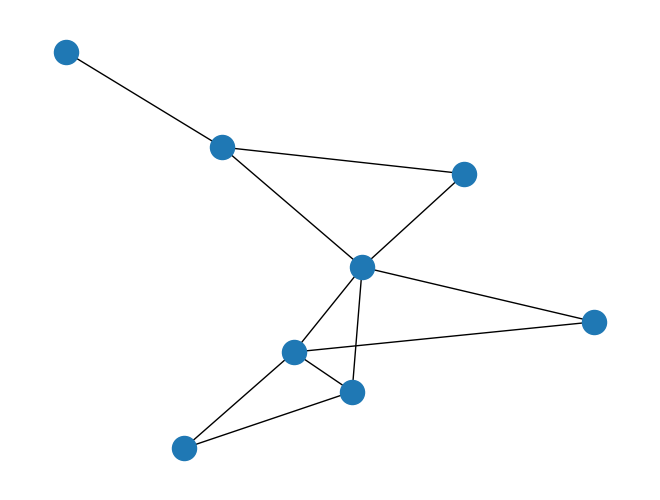

In [14]:
nx.draw(drawing)

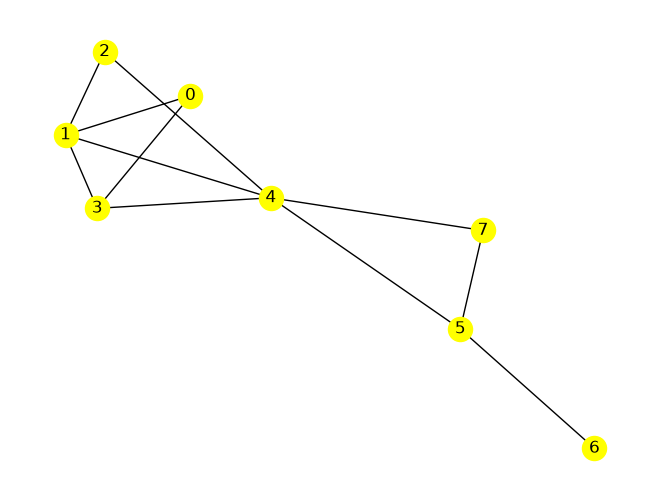

In [19]:
nx.draw(
    drawing, nx.spring_layout(drawing, seed=0), with_labels=True, node_color="yellow"
)

## Overview: LGM (Large Multi-View Gaussian Model)

Introduced at ECCV 2024, **LGM** is a groundbreaking feed-forward framework designed to generate high-resolution 3D models from text prompts or single-view images in roughly 5 seconds.

---

### 1. Intuition First

Traditional text-to-3D methods either relied on painfully slow per-asset optimization (like taking hours running score distillation sampling) or feed-forward models limited by low-resolution internal representations (like coarse Triplanes).

* **The Analogy:** Imagine you want to build a 3D clay sculpture using four photographs taken from different angles. Instead of molding a heavy, solid block voxel-by-voxel, LGM treats every single pixel in those photos as a tiny, soft, colored cloud (a Gaussian primitive). A specialized neural network "splats" these pixels out into 3D space, fusing them together instantly. The result is a crisp, fully textured 3D asset generated almost instantaneously.

---

### 2. Underlying Math & Architecture Details

LGM shifts away from heavy volumetric grids by parameterizing a scene as a dense collection of 3D Gaussians:

* **Gaussian Primitives ($\Theta$):** Each individual Gaussian $i$ is defined by:
* **Center ($\mathbf{x}_i \in \mathbb{R}^3$):** Spatial position $[x, y, z]$.
* **Scale ($\mathbf{s}_i \in \mathbb{R}^3$):** Axis-aligned standard deviations controlling size.
* **Orientation ($\mathbf{q}_i \in \mathbb{R}^4$):** Represented as a unit quaternion for rotation.
    * **Opacity ($\alpha_i \in \mathbb{R}$):** Transparency level.
* **Color Features ($\mathbf{c}_i$):** View-dependent or spherical harmonic color features.


* **Asymmetric U-Net Backbone:** Unlike symmetric U-Nets, LGM uses an asymmetric architecture designed to process multi-view images (typically 4 views produced by a multi-view diffusion model) and map them directly into a massive set of 3D Gaussian parameters with high throughput.
* **Differentiable Rendering:** The fused 3D Gaussians are rendered via fast splatting techniques, enabling end-to-end training supervision directly at a high resolution of $512 \times 512$.

---

### 3. Case Studies & Practical Applications

* **Rapid Asset Prototyping:** Used by game developers and digital artists to turn conceptual text descriptions or 2D sketches into textured 3D assets in seconds.
* **E-Commerce & AR:** Automatically converting single-photo product shots into rotatable 3D items for augmented reality shopping applications.

---

### 4. Terms & Etymology

* **Gaussian Splatting:** Named after **Carl Friedrich Gauss** because the spatial uncertainty of each point is modeled using a Gaussian (bell-shaped) probability distribution. "Splatting" refers to projecting these 3D mathematical primitives onto a 2D viewing screen.
* **Asymmetric U-Net:** Named for its letter "U" shape (contracting encoder and expanding decoder paths). It is "asymmetric" because the feature processing depth and channel configurations differ between the encoder and decoder to optimize multi-view pixel alignment.
* **Feed-Forward Model:** A network that generates outputs in a single forward pass through the weights, avoiding iterative optimization loops.

---

### 5. Practical Implementation (Python Concept)

Below is a conceptual code snippet illustrating how LGM pipelines are typically invoked using modern 3D generation libraries:

```python
import torch
from diffusers import DiffusionPipeline  # Conceptual wrapper for multi-view + LGM pipelines

def generate_3d_from_text(prompt: str, device="cuda"):
    """
    Conceptual implementation of a Large Multi-View Gaussian Model (LGM) pipeline.
    """
    print(f"Generating multi-view images for prompt: '{prompt}'...")

    # Step 1: Generate multi-view images using a diffusion prior (e.g., MVDiffusion/Zero123++)
    # multi_view_images = diffusion_pipeline(prompt).images

    print("Feeding multi-view views into LGM Asymmetric U-Net backbone...")
    # Step 2: Predict 3D Gaussians via LGM feed-forward pass
    # gaussians = lgm_model(multi_view_images)

    # Step 3: Export or render 3D asset (e.g., to .ply or mesh format)
    # gaussians.save_ply("output_asset.ply")

    return "3D Gaussian asset successfully generated!"

# Execution example
# result = generate_3d_from_text("A detailed statue of a futuristic cyberpunk helmet")

```

---

### 6. Current Status: Is it Outdated?

* **Context:** Published in early 2024, LGM was a massive milestone that solved the resolution bottleneck of early feed-forward 3D generators.
* **Current Relevance:** While it remains a foundational baseline for fast multi-view Gaussian fusion, subsequent research has moved past strict 4-view constraints. Modern architectures (emerging through 2025–2026) favor flexible transformer-based models (like Flex3D) that accept an arbitrary number of input views, handle dynamic 4D content (like L4GM), or integrate deeper geometry priors. However, LGM's core concept of pixel-to-Gaussian U-Net splatting remains textbook foundational knowledge for real-time 3D AI.

---

Would you like to dive deeper into the mathematical formulation of 3D Gaussian rendering equations or look at how LGM extracts explicit meshes from raw Gaussians?

# DINO **Self Distillation** with no labels

In standard self-supervised learning with **DINO** (self-**di**stillation with **no** labels), there are **no human-annotated or semantic predefined categories**.

However, DINO relies on an architectural mechanism called **output prototypes (or latent pseudo-categories)**. The projection head outputs a probability distribution over a predefined number of latent prototype dimensions (typically $K = 65,536$ dimensions).

---

### 1. Intuition: Why Pretend There Are "Categories"?

* **The Core Problem:** If an algorithm has no labels, how does it compare two different views of an image without mapping them into an infinite or trivial space?
* **The Clustering Analogy:** Imagine throwing millions of unlabelled photos into a room with $K = 65,536$ distinct buckets. The model is asked: *"If View A of a dog goes into Bucket #4,210, can you make sure View B of the same dog also falls into Bucket #4,210?"*
* **Why They Are Named Prototypes:** They act as prototype vectors (latent visual cluster centers). While human categories look like "dog" or "chair", DINO's emergent prototypes might end up capturing granular visual concepts like "fur texture," "metallic curvature," or "sky gradient".

---

### 2. Underlying Mathematical Mechanics

The projection head maps the feature vector $z \in \mathbb{R}^d$ into a discrete probability distribution over $K$ prototype dimensions via a parameterized weight matrix $W \in \mathbb{R}^{K \times d}$ normalized on a unit sphere.

#### Softmax Probability Formulation

For the student network ($s$) and teacher network ($t$):


$$P_s(x)^{(i)} = \frac{\exp(g_{\theta_s}(x)^{(i)} / \tau_s)}{\sum_{k=1}^{K} \exp(g_{\theta_s}(x)^{(k)} / \tau_s)}$$

$$P_t(x)^{(i)} = \frac{\exp((g_{\theta_t}(x)^{(i)} - c^{(i)}) / \tau_t)}{\sum_{k=1}^{K} \exp((g_{\theta_t}(x)^{(k)} - c^{(k)}) / \tau_t)}$$

* $K$: The predefined number of output dimensions (latent categories/prototypes).
* $c$: The **centering bias**, updated dynamically: $c \leftarrow m c + (1 - m) \frac{1}{B} \sum_{b=1}^{B} g_{\theta_t}(x_b)$. This prevents the network from collapsing into a single dominant pseudo-category.
* $\tau_s, \tau_t$: Temperatures where $\tau_t < \tau_s$ (**sharpening**), forcing the teacher's distribution over the $K$ categories to peak sharply.

#### Cross-Entropy Alignment

The training minimizes the cross-entropy between the teacher's soft pseudo-category distribution and the student's prediction:


$$\mathcal{L} = - \sum_{i=1}^{K} P_t(x')^{(i)} \log P_s(x)^{(i)}$$

                                      ---
### 3. Case Study & Empirical Observations

   * **Granularity vs. Collapse ($K$ size):** In the original DINO paper, setting $K$ to a small number (e.g., $K = 1,000$, matching ImageNet's class count) led to suboptimal transfer performance. Setting $K = 65,536$ provided enough capacity for sub-category visual primitives to self-organize without forcing artificial coarse groupings.

     * **Downstream Alignment:** Even though these $K$ dimensions are never mapped to human classes during pre-training, running a simple **k-NN evaluation** directly on the output space yields strong accuracy on benchmarks like ImageNet, showing that semantic categories emerge automatically without external guidance.

---

### 4. Implementation in Code

A minimal PyTorch snippet demonstrating how the prototype projection head and centering operate over predefined latent dimensions:

```python
import torch
import torch.nn as nn
import torch.nn.functional as F

class DINOHead(nn.Module):
    def __init__(self, in_dim=384, out_dim=65536, hidden_dim=2048, bottleneck_dim=256):
        super().__init__()
        # 3-layer MLP projector followed by L2 normalization and prototype matrix
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, bottleneck_dim),
        )
        # out_dim = K predefined latent categories / prototypes
        self.last_layer = nn.utils.weight_norm(
            nn.Linear(bottleneck_dim, out_dim, bias=False)
        )
        self.last_layer.weight_g.data.fill_(1)
        self.last_layer.weight_g.requires_grad = False

    def forward(self, x):
        x = self.mlp(x)
        x = nn.functional.normalize(x, dim=-1, p=2)
        logits = self.last_layer(x)
        return logits

# Demonstration of Loss with Centering and Sharpening
def dino_loss(student_logits, teacher_logits, center, tau_s=0.1, tau_t=0.04):
    # Teacher outputs: apply centering and sharpening (low temperature)
    teacher_probs = F.softmax((teacher_logits - center) / tau_t, dim=-1).detach()

    # Student outputs: log-softmax at standard temperature
    student_log_probs = F.log_softmax(student_logits / tau_s, dim=-1)

    # Cross-entropy over the K predefined latent categories
    loss = torch.sum(-teacher_probs * student_log_probs, dim=-1).mean()
    return loss

```

---

### 5. Terminology Glossary

* **Latent Prototypes ($K$):** Predefined, learnable vector slots in the projection layer that serve as visual cluster centroids without explicit labels.
* **Centering:** A moving average subtraction applied to teacher activations to prevent one prototype from monopolizing all inputs (preventing mode collapse).
* **Sharpening:** Using a low temperature ($\tau_t$) in the softmax function to make the teacher's distribution peak, mimicking confident pseudo-labels.
* **Self-Distillation:** Training a student network to predict the teacher network's distribution across these unlabelled prototype outputs.

## Pseudocode Student teacher and augmentation


```python
# gs, gt: student and teacher networks
# C: center (K)
# tps, tpt: student and teacher temperatures
# l, m: network and center momentum rates
gt.params = gs.params
for x in loader: # load a minibatch x with n samples
    x1, x2 = augment(x), augment(x) # random views
s1, s2 = gs(x1), gs(x2) # student output n-by-K
t1, t2 = gt(x1), gt(x2) # teacher output n-by-K
loss = H(t1, s2)/2 + H(t2, s1)/2
loss.backward() # back-propagate
# student, teacher and center updates
update(gs) # SGD
gt.params = l*gt.params + (1-l)*gs.params
C = m*C + (1-m)*cat([t1, t2]).mean(dim=0)
def H(t, s):
    t = t.detach() # stop gradient
    s = softmax(s / tps, dim=1)
    t = softmax((t - C) / tpt, dim=1) # center + sharpen
    return - (t * log(s)).sum(dim=1).mean()
```